In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy
import csv

# Exercice 1 

## Question 1 

In [2]:
with open('C:/Users/alice/Desktop/TP_agreg/Corrections_TP/donnees7.1.csv', newline='') as f:
    lignes1=np.array([ligne for ligne in csv.reader(f)])

X=lignes1.astype(float)

with open('C:/Users/alice/Desktop/TP_agreg/Corrections_TP/donnees7.2.csv', newline='') as f:
    lignes2=np.array([ligne for ligne in csv.reader(f)])

Y=lignes2.astype(float)

On suppose que l'une des deux suites est une martingale, alors l'une des deux suites est d'espérance constante. On va donc estimer les vecteurs $(E(X_k))_{1 \le k \le 10}$ et $(E(Y_k))_{1 \le k \le 10}$ via la méthode de Monte-Carlo pour voir lequel semble constant.

In [4]:
Mx=np.mean(X,axis=0)
My=np.mean(Y,axis=0)

print(Mx,My)

[ 0.    0.05  0.1   0.07  0.08 -0.01 -0.03 -0.07 -0.12 -0.18] [0.   1.08 2.16 3.14 4.23 5.29 6.23 7.33 8.47 9.42]


Le vecteur des espérances pour X semble constant, proche de 0, alors que celui de Y pas du tout. C'est donc X qui semble être une martingale.

## Question 2

Estimons (de nouveau par la méthode de Monte-Carlo) le compensateur de $X$. Normalement, le compensateur est donné par la relation $A_k=A_{k-1}+E(Y_k-Y_{k-1}|\mathcal F_{k-1})$ (et $A_0=0$), mais bon, on ne sait pas estimer l'espérance conditionelle, donc on va juste dire $A_k=A_{k-1}+E(Y_k-Y_{k-1})$ (ici c'est en fait ok parce que cette espérance est constante).

In [8]:
A=np.zeros(len(My))
for k in range(1, len(My)):
    A[k]=A[k-1]+My[k]-My[k-1]

print(A)

[0.   1.08 2.16 3.14 4.23 5.29 6.23 7.33 8.47 9.42]


J'ai lu dans les cartes, et elles m'ont dit que le compensateur est le vecteur $[1,...,n]$. (En fait, $X$ est juste une marche aléatoire, et $ Y $ c'est marche aléatoire + $[1,...,n]$.)

# Exercice 2

## Question 1 

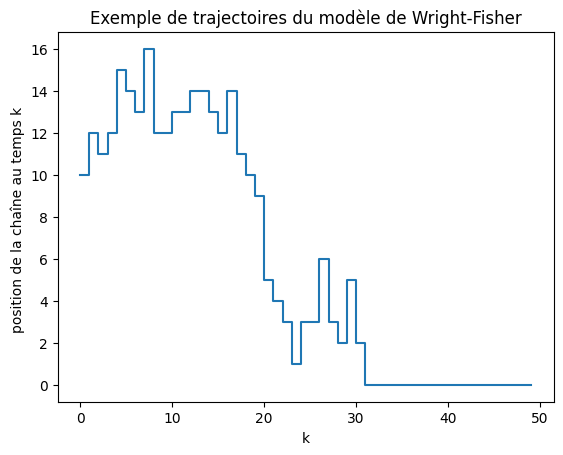

In [11]:
def trajectoire(k,N,n):
    X=np.zeros(n,dtype=int)
    X[0]=k
    for k in range(n-1):
        X[k+1]=stats.binom.rvs(n=N,p=(X[k]/N))
    return(X)

n=50
X=trajectoire(10,20,n)
T=np.arange(0,n)
plt.plot(T,X,drawstyle='steps-post')
plt.xlabel('k')
plt.ylabel('position de la chaîne au temps k ')
plt.title('Exemple de trajectoires du modèle de Wright-Fisher')
plt.show()

## Question 2 

Le théorème d'arrêt (pour $S=0$ et $T$) nous donne $E(X^N_T)=k$.

In [14]:
def simulation_thm_arret(k,N):
    X=[k]
    while (X[-1]!=0) and (X[-1]!=N):
        X.append(stats.binom.rvs(n=N,p=(X[-1]/N)))
    return X[-1]

k=4
N=10
X_T=[simulation_thm_arret(k,N) for _ in range (1000)]
E=np.mean(X_T)
print(E) # renvoie une valeur proche de k

4.12


## Question 3 

On déduit de l'égalité $E(X^N_T)=k$ la loi de $X^N_T$ : 
$$P(X^N_T=N)= \frac k N \quad \text{ et } \quad  P(X^N_T=0)=N- \frac k N. $$
Illustrons cela par la méthode de Monte-Carlo.

In [15]:
k=4
N=10
X_T=[1*(simulation_thm_arret(k,N)==N) for _ in range (1000)]
E=np.mean(X_T)*N
print(E) # renvoie une valeur proche de k

4.109999999999999


# Exercice 3 

## Question 1 

Pour tout $n \ge 1$, on a, par indépendance :
$$Var (M_n^2) =  \sum_{k=1}^n \frac{Var{X_k}}{k^2} = \sum_{k=1}^n \frac{1}{k^2} < \sum_{k=1}^{+\infty} \frac{1}{k^2} < + \infty.$$
Donc la martingale est bornée dans $L^2$, et ainsi convergence p.s. et dans $L^2$. 

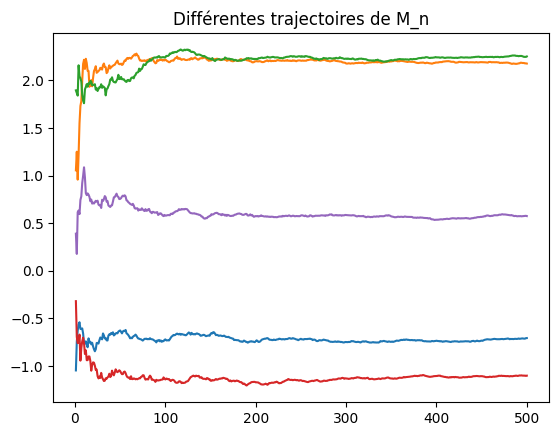

In [3]:
# Pour illustrer la convergence p.s., on va juste tracer plusieurs trajectoires pour montrer qu'elles sont toutes convergentes. 
n=500
N=np.arange(1,n+1)
X1=np.cumsum(stats.norm.rvs(size=n)/N)
X2=np.cumsum(stats.norm.rvs(size=n)/N)
X3=np.cumsum(stats.norm.rvs(size=n)/N)
X4=np.cumsum(stats.norm.rvs(size=n)/N)
X5=np.cumsum(stats.norm.rvs(size=n)/N)
plt.plot(N,X1)
plt.plot(N,X2)
plt.plot(N,X3)
plt.plot(N,X4)
plt.plot(N,X5)
plt.title('Différentes trajectoires de M_n') 
plt.show()

## Question 2 

Pour tout $n \ge 1,$
$$M_n \sim \mathcal N \left ( 0, \sum_{k=1}^n \frac{1}{k^2} \right), $$
avec 
$$ \sum_{k=1}^n \frac{1}{k^2}  \xrightarrow[n \to \infty]{} \sum_{k=1}^{+ \infty} \frac{1}{k^2} = \frac {\pi ^2}{6}. $$
Donc 
$$M_n  \xrightarrow[n \to \infty]{\mathcal L} \mathcal N \left ( 0, \frac {\pi ^2}{6} \right).$$
(Propriété gaussienne : Une suite de variables de loi normale $\mathcal N(m_n, \sigma_n)$ converge en loi ssi $m_n  \xrightarrow[n \to \infty]{} m$ et $\sigma_n  \xrightarrow[n \to \infty]{} \sigma$, et la limite est alors la loi normale $\mathcal N(m,\sigma)$.)

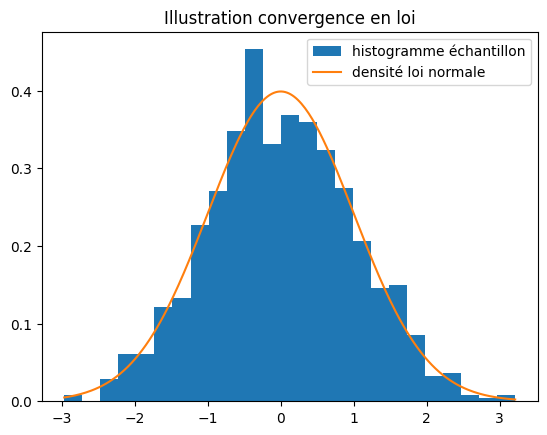

0.7294415746007852
On ne rejette pas H0


In [39]:
n=1000
N=1000
M=[]
for _ in range (N): 
    M.append(np.sum(stats.norm.rvs(size=n)/np.arange(1,n+1)))
M=(sqrt(6)/pi)*np.array(M)
plt.hist(M,25,density='True', label='histogramme échantillon')
X=np.linspace(min(M),max(M),250)
plt.plot(X,stats.norm.pdf(X),label='densité loi normale')
plt.legend()
plt.title('Illustration convergence en loi')
plt.show()

# En bonus, un petit test de Kolmogorov Smiernov : 
alpha=0.05
D,p_valeur=stats.kstest(M,stats.norm.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")
# Tout le monde est convaincu :) 

## Question 3 

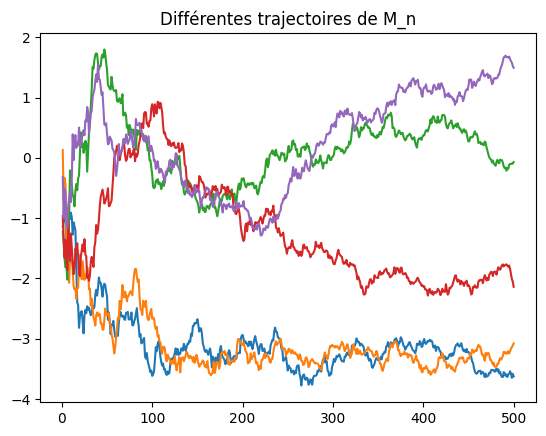

In [62]:
# Regardons quelques trajectoires 
n=500
N=np.arange(1,n+1)
N2=np.sqrt(N)
X1=np.cumsum(stats.norm.rvs(size=n)/N2)
X2=np.cumsum(stats.norm.rvs(size=n)/N2)
X3=np.cumsum(stats.norm.rvs(size=n)/N2)
X4=np.cumsum(stats.norm.rvs(size=n)/N2)
X5=np.cumsum(stats.norm.rvs(size=n)/N2)
plt.plot(N,X1)
plt.plot(N,X2)
plt.plot(N,X3)
plt.plot(N,X4)
plt.plot(N,X5)
plt.title('Différentes trajectoires de M_n') 
plt.show()
# Ca a l'air assez peu convergent... 

## Question 4 

On a cette fois, pour tout $n \ge 1$ (toujours par indépendance) :
$$Var (N_n^2) =  \sum_{k=1}^n \frac{Var{X_k}}{k} = \sum_{k=1}^n \frac{1}{k}.$$
En définissant 
$$h_n := \sum_{k=1}^n \frac 1 k,$$
on a alors (par le TCL de Lindeberg) : 
$$ \frac {N_n}{\sqrt h_n} \xrightarrow[n \to \infty]{\mathcal L} \mathcal N(0,1).$$

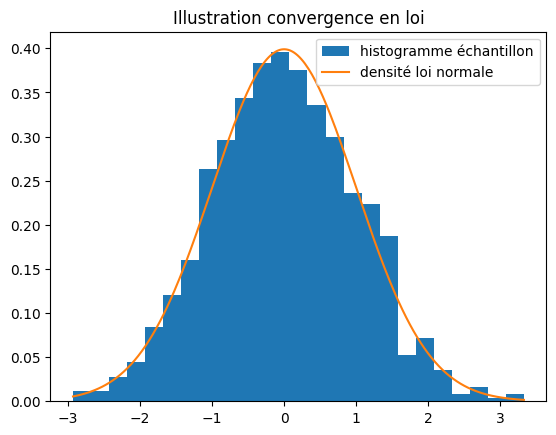

0.6844036206721497
On ne rejette pas H0


In [38]:
n=1000
N=1000
M=[]
hn=np.sum(1/np.arange(1,n+1))
for _ in range (N): 
    M.append(np.sum(stats.norm.rvs(size=n)/np.sqrt(np.arange(1,n+1))))
M=np.array(M)/sqrt(hn)
plt.hist(M,25,density='True', label='histogramme échantillon')
X=np.linspace(min(M),max(M),250)
plt.plot(X,stats.norm.pdf(X),label='densité loi normale')
plt.legend()
plt.title('Illustration convergence en loi')
plt.show()

# Encore en bonus, un petit test de Kolmogorov Smiernov : 
alpha=0.05
D,p_valeur=stats.kstest(M,stats.norm.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")
# Tout le monde est convaincu :) 

# Exercice 4

## Question 1 

In [3]:
def traj_polya(N0,B0,n): 
    N=N0
    B=B0
    X=[B0/(B0+N0)]
    for _ in range (n):
        b=stats.binom.rvs(n=1,p=B/(B+N)) # vaut 1 si on tire une boule blanche, 0 si on en tire une noire 
        if b==1:
            B+=1
        else : 
            N+=1
        X.append(B/(B+N))
    return(np.array(X))

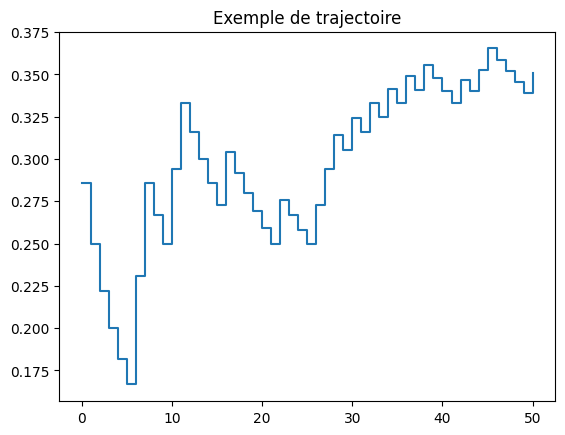

In [6]:
n=50
X=traj_polya(5,2,n)
plt.plot(np.arange(n+1),X,drawstyle='steps-post')
plt.title('Exemple de trajectoire')
plt.show()

## Question 2 

La martingale est bornée (donc bornée dans $L^1$ par exemple), et ainsi elle converge presque sûrement. Comme précédemment, on l'illustre en traçant plusieurs trajectoires. 

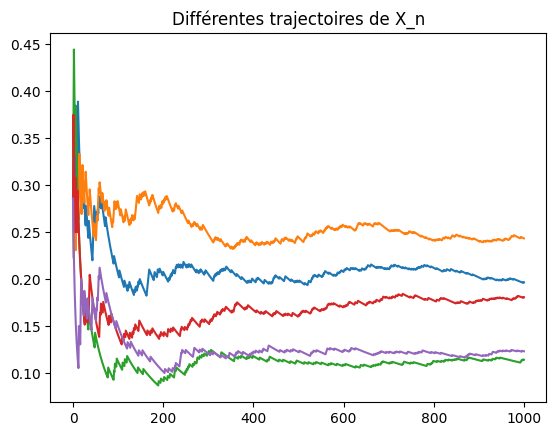

In [49]:
n=1000
B0=2
N0=5
N=np.arange(0,n+1)
plt.plot(N,traj_polya(N0,B0,n))
plt.plot(N,traj_polya(N0,B0,n))
plt.plot(N,traj_polya(N0,B0,n))
plt.plot(N,traj_polya(N0,B0,n))
plt.plot(N,traj_polya(N0,B0,n))
plt.title('Différentes trajectoires de X_n')
plt.show()

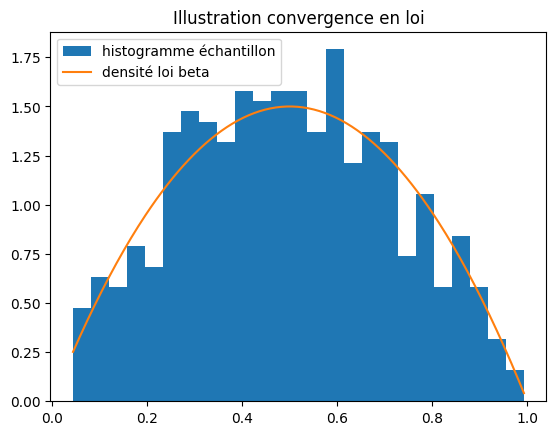

In [54]:
n=1000
N=500
B0=2
N0=2
X=[]
for _ in range (N): 
    X.append(traj_polya(N0,B0,n)[-1])
plt.hist(X,25,density='True', label='histogramme échantillon')
T=np.linspace(min(X),max(X),250)
plt.plot(T,stats.beta.pdf(T, a=N0, b=B0),label='densité loi beta')
plt.legend()
plt.title('Illustration convergence en loi')
plt.show()

## Question 4 

Si $B_0=1$ et $N_0=1$, alors la loi beta limite est juste la loi uniforme sur $(0,1)$. 

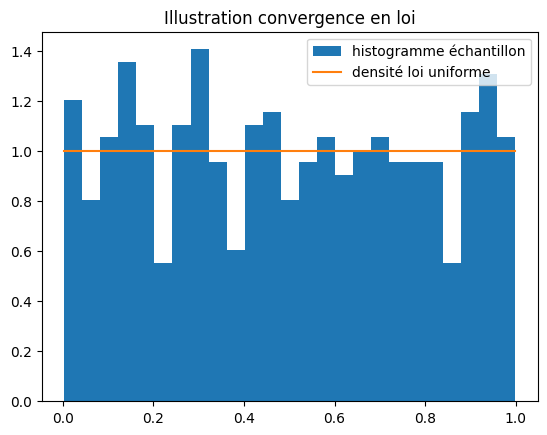

0.9355973544588814
On ne rejette pas H0


In [57]:
n=1000
N=500
X=[]
for _ in range (N): 
    X.append(traj_polya(1,1,n)[-1])
plt.hist(X,25,density='True', label='histogramme échantillon')
T=np.linspace(min(X),max(X),250)
plt.plot(T,stats.uniform.pdf(T, loc=0, scale=1),label='densité loi uniforme')
plt.legend()
plt.title('Illustration convergence en loi')
plt.show()

# En bonus, un petit test de Kolmogorov Smiernov : 
alpha=0.05
D,p_valeur=stats.kstest(X,stats.uniform.cdf)
print(p_valeur)
if p_valeur<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")
# Tout le monde est convaincu :) 

# Exercice 5

## Question 1 

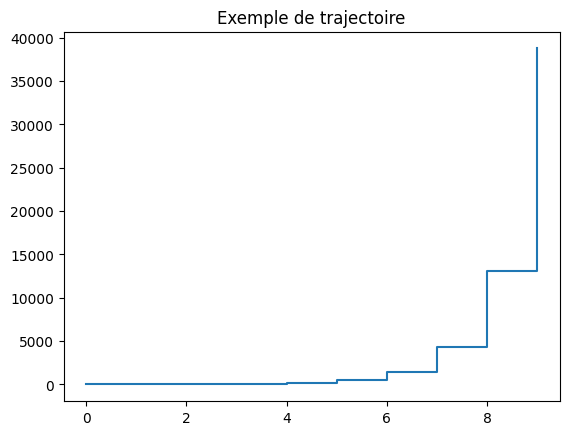

In [3]:
def traj_GW(n,p):
    z=1
    Z=[z]
    for _ in range (n-1): 
        if z==0: 
            Z.append(0)
        else: 
            X=stats.geom.rvs(p,size=z)-1 # la loi P est la loi d'une variable géométrique décalée de 1 
            z=np.sum(X)
            Z.append(z)
    return(np.array(Z))

n=10 # prenez n petit, ça grandit TRES vite !
p=1/4
Z=traj_GW(n,p)
plt.plot(np.arange(n),Z,drawstyle='steps-post')
plt.title('Exemple de trajectoire')
plt.show()

## Question 2

In [12]:
n=5 # je diminue encore n parce que ça devient vite long avec Monte-Carlo (et je suis impatiente)
N=2000
m=(1-p)/p
M=np.zeros(N)
for i in range (N):
    Z=traj_GW(n,p)
    M[i]=Z[-1]
print('valeur théorique', m**n)
print('estimation', np.mean(M))

valeur théorique 243.0
estimation 245.1815


## Question 3 

A partir d'ici, il vaut mieux prendre $p = \frac 1 2$ (auquel cas la proba que $T$ soit fini est égale à 1) pour éviter les longues trajectoires... O, va quand même devoir mettre un seuil d'arrêt, mais avec $p$ plus petit (même proche de 1/2), ça arrive beaucoup plus régulièrement d'aller jusqu'au seuil et ça devient vraiment trop long...

In [2]:
def extinction(p,seuil): # simule un temps d'extinction : renvoie True s'il semble fini, False sinon 
    z=1
    t=1
    while (z!=0) and (t<seuil) :
        X=stats.geom.rvs(p,size=z)-1 
        z=np.sum(X)
    if z==0:
        return(True)
    else : 
        return(False)

p=1/2
N=1000
P=0
for _ in range (N):
    P+=extinction(p,50)
print(P/N) 
# On trouve bien 1, yeay !

1.0


## Question 4 

Le cas $m=1$ correspond au cas $p= \frac 1 2 $, et dans ce cas, $\sigma^2 = 2$. 

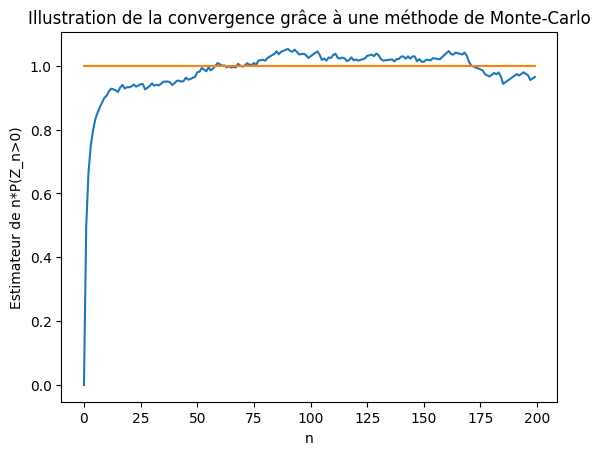

In [22]:
# Question a)
def extinction_n(n,p): # renvoie un vecteur de True et False : True au rang i si Z_i>0, et False sinon 
    Z=traj_GW(n,p)
    return(Z>0)

p=1/2
N=20000 # il faut prendre N assez grand pour avoir un nombre significatif de trajectoires non nulles jusqu'au rang n
n=200 # il faut alors sacrifier n pour rester raisonnable en temps de calcul... 
l=1
M=np.array([extinction_n(n,p) for _ in range (N)])
P=np.mean(M,axis=0)
plt.plot(np.arange(n),P*np.arange(n))
plt.plot(np.arange(n),l*np.ones(n))
plt.title('Illustration de la convergence grâce à une méthode de Monte-Carlo')
plt.xlabel('n')
plt.ylabel('Estimateur de n*P(Z_n>0)')
plt.show()

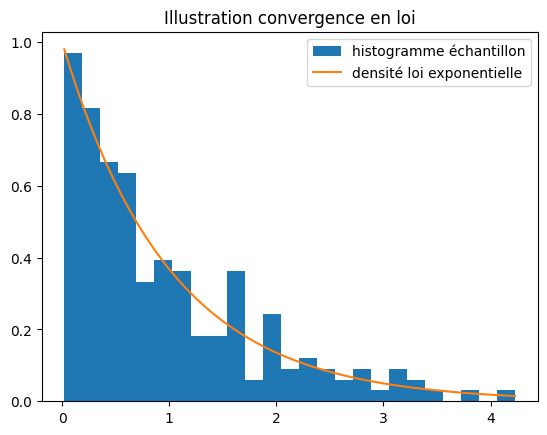

In [20]:
# Question b) 
p=1/2
N=20000 # même chose ici : il faut prendre N très grand pour avoir un échantillon (conditionnel) suffisamment grand 
n=100 # même contrepartie, il faut diminuer n 
E=[]
z=0
for _ in range (N):
    z=traj_GW(n,p)[-1]
    if z!=0: 
        E.append(z/n)
plt.hist(E,25,density='True', label='histogramme échantillon')
T=np.linspace(min(E),max(E),250)
plt.plot(T,stats.expon.pdf(T),label='densité loi exponentielle')
plt.legend()
plt.title('Illustration convergence en loi')
plt.show()

## Question 5 

Les codes à venir sont seulement "théoriques", il serait vraiment trop long de les faire tourner... (Une seule trajectoire à 100 pas c'est déjà interminable, alors une méthode de Monte Carlo sur l'espérance de la loi limite, n'en parlons pas...)

In [ ]:
# Illustration de la convergence p.s. 
p=1/4
n=1000
m=(1-p)/p
Z1=traj_GW(n,p)
Z2=traj_GW(n,p)
Z3=traj_GW(n,p)
Z4=traj_GW(n,p)
Z5=traj_GW(n,p)
M=m**np.arange(n)
plt.plot(np.arange(n),Z1/M)
plt.plot(np.arange(n),Z2/M)
plt.plot(np.arange(n),Z3/M)
plt.plot(np.arange(n),Z4/M)
plt.plot(np.arange(n),Z5/M)
plt.title('Exemples de trajectoires')
plt.show()

# Dans l'idée, ça donnerait plusieurs jolies courbes qui convergent toutes, et qui illustrent la convergence presque sûre. 

In [ ]:
# Estimation de l'espérance et de la variance 
p=1/4
n=1000
N=1000
Y=np.zeros(N)
for i in range (N):
    Y[i]=traj_GW(n,p)[-1]
M=np.mean(Y) # estimateur de la moyenne
V=np.mean((Y-M)**2) # estimateur de la variance 
print(M,V)